In [1]:
import os
import shutil
import logging
import matplotlib.pyplot as plt
import numpy as np
dir_path = "."
os.chdir(dir_path)
print(os.getcwd())

from simulation import Simulation
from funcs import plot_paths, overlay_paths

%matplotlib inline

# Working directory for the simulation
## MODIFY ##
work_dir = "./simulations/newtest"

if os.path.exists(work_dir):
    shutil.rmtree(work_dir)
if not os.path.exists(work_dir):
    os.mkdir(work_dir)
# copy all py files of cwd to test
for file in os.listdir(os.getcwd()):
    if file.endswith(".py") or file.endswith(".png"):
        shutil.copy(file, work_dir)
shutil.copytree(os.getcwd() + "/potentials", work_dir + "/potentials", dirs_exist_ok=True)
os.chdir(work_dir)
print(os.getcwd())

/mnt/0bf0c339-34bb-4500-a5fb-f3c2a863de29/DATA/PyRETIS3/toytis
/mnt/0bf0c339-34bb-4500-a5fb-f3c2a863de29/DATA/PyRETIS3/toytis/simulations/newtest


In [ ]:
###### 2D POTENTIALS #####

# Interfaces (list)
## MODIFY ##

lambA = -2.3
lambB = 2.3
N_intfs = 10

intfs = np.linspace(lambA, lambB, N_intfs).tolist()  


In [ ]:
# Set-up the simulation keys for RETIS
retisset = {"interfaces" : intfs,
             "simtype" : "retis", 
             "method" : "load",
             "max_len" : 200000,
             "dt": 0.01,
             "temperature": 0.07,
             "friction": 25.,
             "high_friction": False,
             "max_cycles": 100000,
             "p_shoot": 0.9,        
             "include_stateB": False,
             'prime_both_starts': False,
             'snake_Lmax': 0,
             'max_paths': 5,
             'save_pe2': False,
             'pe2_N': 0,
             "dim": 2,
             "mass": 1,
             'permeability': False,
             'zero_left': 0.2,
             'v_ord': False,
}

# or for REPPTIS
repptisset = {"interfaces" : intfs,
             "simtype" : "repptis", 
             "method" : "load",
             "max_len" : 200000,
             "dt": 0.01,
             "temperature": 0.07,
             "high_friction": False,
             "friction": 25.,
             "max_cycles": 100000,
             "p_shoot": 0.9,
             "include_stateB": False,
             'prime_both_starts': True,
             'snake_Lmax': 0,
             'max_paths': 5,
             'save_pe2': False,
             'pe2_N': 0,
             "mass": 1,
             "dim": 2,
             'permeability': False,
             'zero_left': 0.2
}

istarset = {"interfaces" : intfs,
                "simtype" : "i*", 
                "method" : "load",
                "max_len" : 200000,
                "dt": 0.01,
                "temperature": 0.07,
                "friction": 5.,
                "high_friction": False,
                "max_cycles": 10000,
                "p_shoot": 0.9,        
                "include_stateB": False,
                'prime_both_starts': True,
                'snake_Lmax': 0,
                'max_paths': 5,
                "dim": 2,
                "mass": 1,
                'permeability': False,
                'zero_left': 0.2,
                'v_ord': False,    # also save velocity as OP in the order.txt file
    }


logger = logging.getLogger()
file_handler = logging.FileHandler("logging.log")
formatter = logging.Formatter('[%(levelname)s] [[%(asctime)s]] %(name)s %(funcName)s %(lineno)d: %(message)s')
file_handler.setFormatter(formatter)
logger.addHandler(file_handler)
logger.setLevel(logging.INFO)
logger.info("\ninterfaces = {}\n".format(intfs) +
            #  "zero_left = {}\n".format(istarset["zero_left"]) +
             "timestep = {}\n".format(istarset["dt"]))
sim = Simulation(istarset)
logger.info("Full settings:\n{}".format(sim.settings))
# set lolevel to warning for matplotlib
logging.getLogger("matplotlib").setLevel(logging.DEBUG)

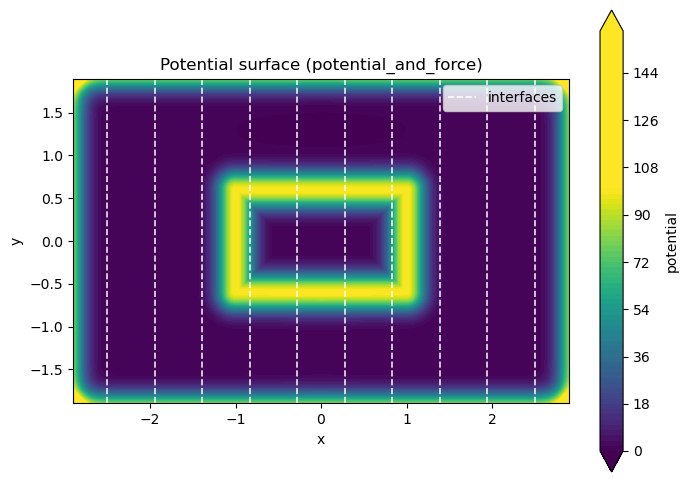

In [13]:
# get grid potential via potential_and_force
xmax, xmin = 2.9, -2.9
ymax, ymin = 1.9, -1.9
Nx = 600
Ny = int(Nx * (ymax - ymin) / (xmax - xmin))
xvals = np.linspace(-2.9, 2.9, Nx)
yvals = np.linspace(-1.9, 1.9, Ny)
potvals = np.zeros((Nx, Ny))
for i, x in enumerate(xvals):
    for j, y in enumerate(yvals):
        potvals[i, j], _ = sim.ensembles[0].engine.potential.potential_and_force(
            (np.array([x, y]), np.array([0., 0.]))
        )

fig, ax = plt.subplots(figsize=(8, 6))

# vmin = np.min(potvals)
# vmax = np.max(potvals)

vmin = 0
vmax = 100

cs = ax.contourf(xvals, yvals, potvals.T, 100, cmap="viridis", vmin=vmin, vmax=vmax, extend="both")

# add interfaces
for k, intf in enumerate(sim.intfs):
    ax.axvline(intf, color="white", linestyle="--", linewidth=1.2, alpha=0.9,
               label="interfaces" if k == 0 else None)


ax.set_title("Potential surface (potential_and_force)")
ax.set_xlabel("x")
ax.set_aspect("equal")
ax.set_ylabel("y")
ax.legend(loc="upper right")

fig.colorbar(cs, ax=ax, label="potential", extend="both")
plt.show()

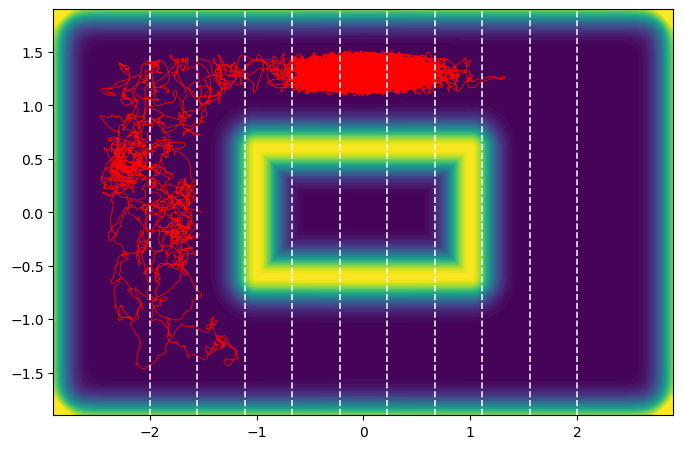

In [11]:
phasepoint = (np.array([-1.5, 0.]), np.array([0., 0.]))

Nsteps = 500000

phasepoints = np.zeros((Nsteps, 2))
phasepoints[0] = phasepoint[0]

for step in range(1, Nsteps):
    phasepoint = sim.ensembles[0].engine.step(phasepoint)
    phasepoints[step] = phasepoint[0]
    
# plot the potential and the trajectory of the particle
fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(xvals, yvals, potvals.T, 100, cmap="viridis", vmin=vmin, vmax=vmax, extend="both")
ax.plot(phasepoints[:, 0], phasepoints[:, 1], color="red", linewidth=0.6, label="trajectory")
ax.set_aspect("equal")
for intf in sim.intfs:
    ax.axvline(intf, color="white", linestyle="--", linewidth=1.2, alpha=0.9)
